In [2]:
%cd /content/15x6-sim
# or wherever you cloned it, e.g. /content/drive/MyDrive/Projects/15x6-sim
!pwd
!ls data/
!git clone https://github.com/MementoMori15x6/15x6-sim.git
%cd 15x6-sim
!pip install pandas numpy matplotlib seaborn scipy


[Errno 2] No such file or directory: '/content/15x6-sim'
/content
/content
ls: cannot access 'data/': No such file or directory
Cloning into '15x6-sim'...
remote: Enumerating objects: 1338, done.
remote: Counting objects: 100% (184/184), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 1338 (delta 146), reused 75 (delta 75), pack-reused 1154 (from 2)
Receiving objects: 100% (1338/1338), 6.70 MiB | 18.91 MiB/s, done.
Resolving deltas: 100% (765/765), done.
/content/15x6-sim


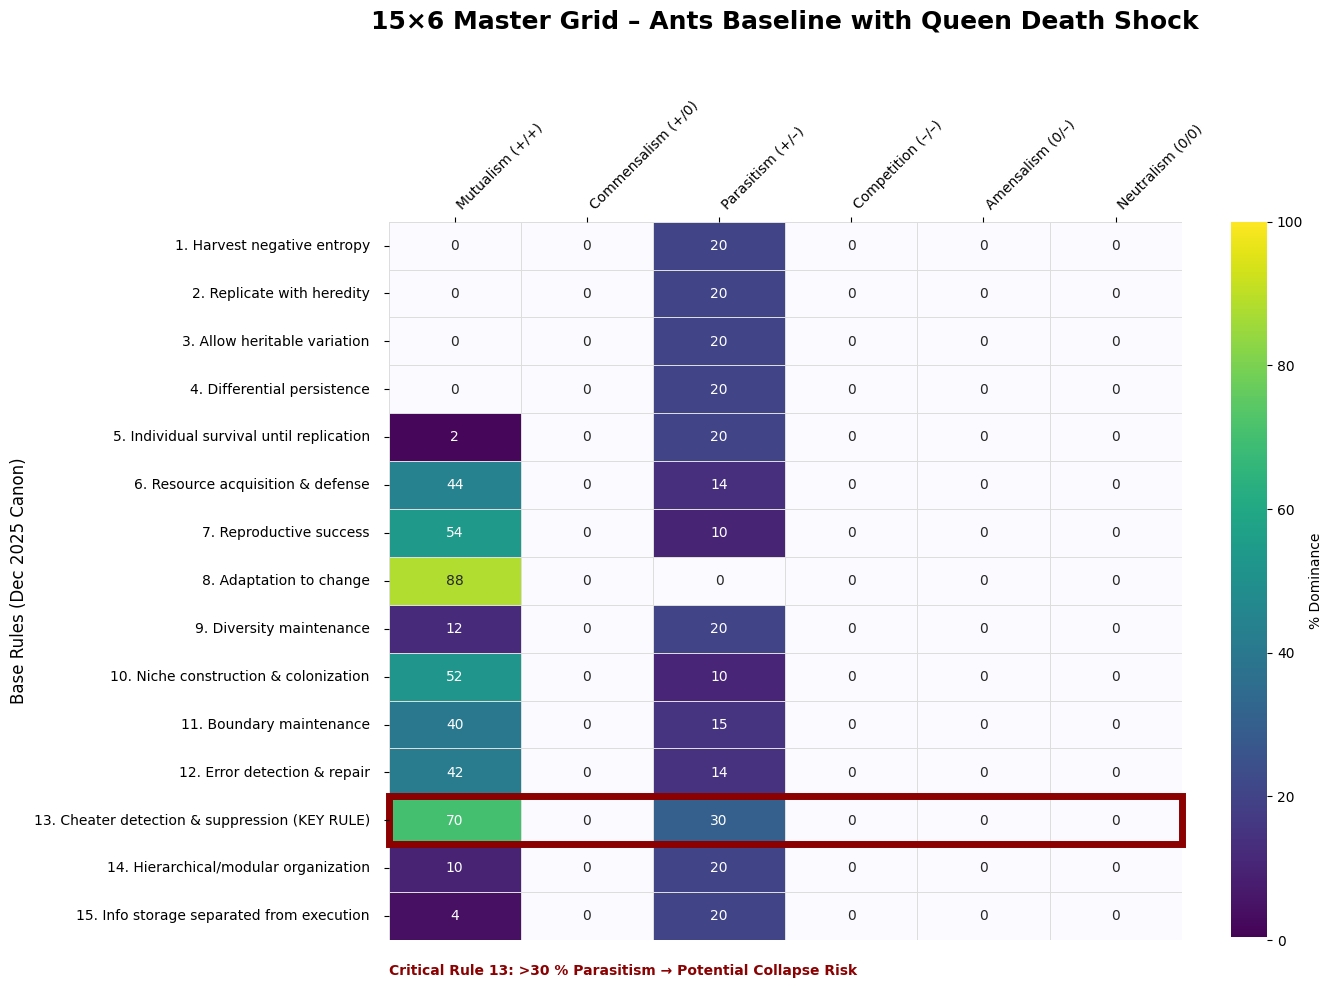

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from google.colab import files

# Load baseline scores
df = pd.read_csv("examples/eusocial_ant_colony.csv")
scores = df['Score'].astype(float).values

# Canonical labels (your master blank)
rules = [
    "1. Harvest negative entropy",
    "2. Replicate with heredity",
    "3. Allow heritable variation",
    "4. Differential persistence",
    "5. Individual survival until replication",
    "6. Resource acquisition & defense",
    "7. Reproductive success",
    "8. Adaptation to change",
    "9. Diversity maintenance",
    "10. Niche construction & colonization",
    "11. Boundary maintenance",
    "12. Error detection & repair",
    "13. Cheater detection & suppression (KEY RULE)",
    "14. Hierarchical/modular organization",
    "15. Info storage separated from execution"
]
moves = [
    "Mutualism (+/+)",
    "Commensalism (+/0)",
    "Parasitism (+/–)",
    "Competition (–/–)",
    "Amensalism (0/–)",
    "Neutralism (0/0)"
]

# Apply queen death shock
shocked_vector = scores.copy()
shocked_vector[29] -= 10  # L1 succession mechanism
shocked_vector[30] -= 10  # L2 leadership cult

# Refined dominance mapping (same as baseline v5)
dominance = np.zeros((15, 6))
for r in range(15):
    score = shocked_vector[r]
    mutual = max(0, score * 8 + 80)  # baseline boost
    mutual = min(100, mutual)
    dominance[r, 0] = mutual

    parasit = max(0, -score * 3) if score < -3 else 0
    dominance[r, 2] = min(20, parasit)  # allow bleed on shock

# Lock shocked Rule-13 (increased bleed)
dominance[12, 0] = 70
dominance[12, 2] = 30

# Your master blank style
viridis_base = mpl.colormaps["viridis"]
newcolors = viridis_base(np.linspace(0, 1, 256))
newcolors[0, :] = [0.98, 0.98, 1, 1]
custom_map = LinearSegmentedColormap.from_list('FullSaturation', newcolors)
oxford_red = "#8B0000"

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(dominance, annot=True, fmt=".0f", cmap=custom_map, vmin=0, vmax=100,
            linewidths=0.5, linecolor="#dddddd", cbar_kws={'label': '% Dominance', 'pad': 0.05}, ax=ax,
            xticklabels=moves, yticklabels=rules)

ax.set_title("15×6 Master Grid – Ants Baseline with Queen Death Shock", fontsize=18, pad=50, fontweight='bold')
ax.set_ylabel("Base Rules (Dec 2025 Canon)", fontsize=12)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(rotation=45, ha="left", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
ax.tick_params(axis='y', which='major', pad=10)

# Red Rule-13 border (fractured)
ax.add_patch(plt.Rectangle((0, 12), 6, 1, fill=False, edgecolor=oxford_red, lw=5, clip_on=False))

# Critical note
ax.text(0, 15.5, "Critical Rule 13: >30 % Parasitism → Potential Collapse Risk",
        fontsize=10, color=oxford_red, ha='left', va='top', fontweight='bold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

plt.tight_layout()
plt.savefig("tests/outputs/ants_shocked_queen_death_lattice_v2.png", dpi=300, bbox_inches="tight")
plt.show()

files.download("tests/outputs/ants_shocked_queen_death_lattice_v2.png")

In [ ]:
!python simulate.py

Loading CSV: examples/eusocial_ant_colony.csv
DF shape: (35, 4)
DF columns: ['Metric', 'Description', 'Score', 'Rationale']
  Metric  ...                                          Rationale
0     A1  ...  No individual property exists; all resources a...
1     A2  ...  Resource distribution occurs through pheromone...

[2 rows x 4 columns]
Extracted 35 numeric scores

--- Ants Consensus Baseline ---
X: -0.60 | Y: -2.18 | Zone: 1
Rule-13 Parasitism Proxy: 0.6%
Estimated longevity window: ~97–180 years
 (Sensitivity: ±20% on parasitism would shift range to ~77–217 years)
Success: Grid saved to tests/outputs/ants_consensus_lattice.png
